# Data Engineering Patterns and Optimisation

## Preparation

Run this cells if you don't use an environment such as Databricks.

In [ ]:
!pip install -q pyspark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import *

In [ ]:
spark = SparkSession.builder.appName("Spark lessons").getOrCreate()
# .master('local[*]') # run locally on all the CPUs

## Adaptive Query Execution (AQE)

`AQE` dynamically adjusts Spark's physical execution plan at runtime using collected statistics (partition sizes, table sizes, skew) to improve performance. Turn `AQE` off for experiments here.

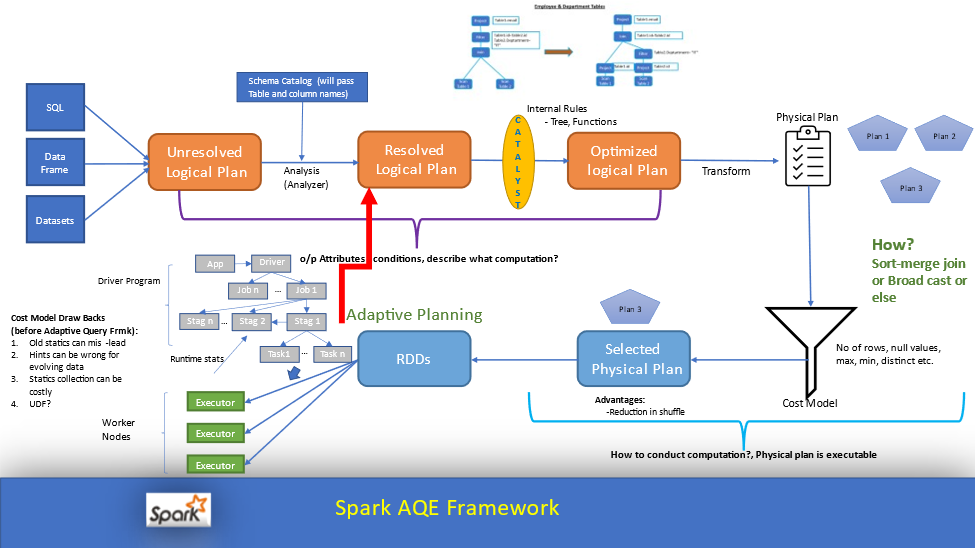

In [ ]:
spark.conf.set('spark.sql.adaptive.enabled', 'false')

In [ ]:
spark.conf.get('spark.sql.adaptive.enabled')

'false'

In [ ]:
from pathlib import Path

def getpath(file):
    return str(DIR / file)

!wget -O "/content/BigMart Sales.csv" "https://raw.githubusercontent.com/anshlambagit/PySpark-Full-Course/main/DATA%20and%20NOTEBOOK/BigMart%20Sales.csv"
DIR = Path('/content/')

--2026-05-03 18:50:22--  https://raw.githubusercontent.com/anshlambagit/PySpark-Full-Course/main/DATA%20and%20NOTEBOOK/BigMart%20Sales.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 869537 (849K) [text/plain]
Saving to: ‘/content/BigMart Sales.csv’

/content/BigMart Sa 100%[===================>] 849.16K  --.-KB/s    in 0.05s   

2026-05-03 18:50:22 (16.6 MB/s) - ‘/content/BigMart Sales.csv’ saved [869537/869537]



In [ ]:
df = spark.read.format('csv') \
    .option('inferSchema', True) \
    .option('header', True) \
    .load(getpath('BigMart Sales.csv'))
df.toPandas()

Now, enable `AQE`.

In [ ]:
spark.conf.set('spark.sql.adaptive.enabled', 'true')

In [ ]:
df = spark.read.format('csv') \
    .option('inferSchema', True) \
    .option('header', True) \
    .load(getpath('BigMart Sales.csv'))

In [ ]:
df_new = df.groupBy('Item_fat_Content').count()
df_new.toPandas()

,Item_fat_Content,count
0,low fat,112
1,Low Fat,5089
2,LF,316
3,Regular,2889
4,reg,117


## Auto Loader

Auto Loader continuously monitors specified directories for new files and ingests them into `Delta` tables or DataFrames. Idempotence is the property of an operation that ensures performing it multiple times produces the same result as performing it once, and Auto Loader is applied to each file this way. It writes the stream state to a special storage called `rocksDB` and tracks processed files to ensure idempotency and prevent data duplication.

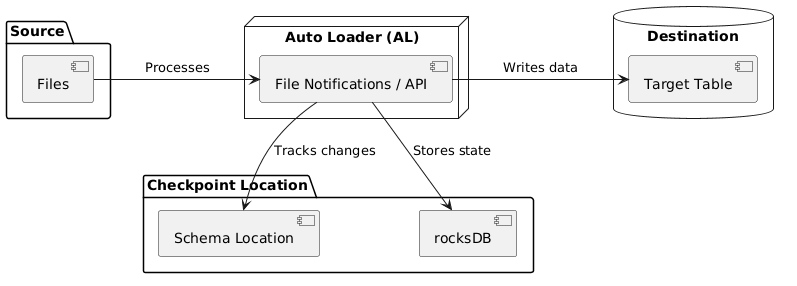

Make necessary directories we will use for operations.

In [ ]:
dbutils.fs.mkdirs("/Volumes/workspace/default/study/raw_source")
dbutils.fs.mkdirs("/Volumes/workspace/default/study/raw_destination/data")
dbutils.fs.mkdirs("/Volumes/workspace/default/study/raw_destination/checkpoint")
dbutils.fs.mkdirs("/Volumes/workspace/default/study/raw_destination/schema")

True

Create a file the loader will read. After reading it once it won't track any other changes — reading is idempotent.

In [ ]:
dbutils.fs.put(
  "/Volumes/workspace/default/study/raw_source/test.csv",
  "a,b\n1,2\n3,4",
  True
)

Wrote 11 bytes.


True

Auto Loader tracks `/raw_source` for new `CSV` files. Checkpoints are written to `rocksDB` stored in `/raw_destination/checkpoint`. When adding new files with different schemas to an existing `Delta` table, the `mergeSchema=True` parameter allows for automatically merging new schemas with the existing ones. Stream execution is controlled by triggers, e. g.:

- `availableNow=True`,
- `processingTime='3 seconds'`.

In [ ]:
df = spark.readStream.format("cloudFiles") \
    .option("cloudFiles.format", "csv") \
    .option('cloudFiles.schemaEvolutionMode', 'addNewColumns') \
    .option("cloudFiles.schemaLocation", "/Volumes/workspace/default/study/raw_destination/schema") \
    .load("/Volumes/workspace/default/study/raw_source")

df.writeStream.format("delta") \
    .option("checkpointLocation", "/Volumes/workspace/default/study/raw_destination/checkpoint") \
    .trigger(availableNow=True) \
    .option('mergeSchema', True) \
    .start("/Volumes/workspace/default/study/raw_destination/data")

Read the file from the destination folder.

In [ ]:
spark.read.format("delta").load("/Volumes/workspace/default/study/raw_destination/data").display()

a,b,_rescued_data
1,2,null
3,4,null


Write a new file with a new schema and rerun the Auto Loader cell.

In [ ]:
dbutils.fs.put(
  "/Volumes/workspace/default/study/raw_source/test_2.csv",
  "a,b,c\n2,2,2\n3,4,5",
  True
)

Wrote 17 bytes.


True

In [ ]:
spark.read.format("delta").load("/Volumes/workspace/default/study/raw_destination/data").display()

a,b,_rescued_data,c
2,2,null,2
3,4,null,5
1,2,null,null
3,4,null,null


## Slowly Changing Dimension (SCD)

`SCD` is a data warehousing concept focused on managing and storing historical data related to attributes that change over time. For example, if a row is going to be changed, we can store only the last version, all the available or only the actual and the previous one. `SCD` is based on upsertion. `Upsert` (update and insert) is a logic that either updates an existing row if it finds a match or inserts a new one if it doesn't. We save states to the `rockDB` checkpoint and keep the actual data and logs at `Delta`.

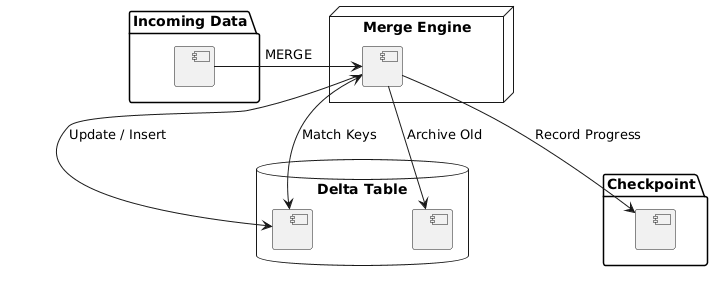

Load the data.

In [ ]:
%sh
wget -O repo.zip "https://github.com/anshlambagit/PySpark-RealTime-Scenarios-with-Python/archive/refs/heads/main.zip"
unzip -o repo.zip
cp PySpark-RealTime-Scenarios-with-Python-main/Raw\ Data/*.csv /Volumes/workspace/default/study/
mv "/Volumes/workspace/default/study/products_dim_table.csv" "/Volumes/workspace/default/study/rawcsv/"

--2026-05-03 15:41:20--  https://github.com/anshlambagit/PySpark-RealTime-Scenarios-with-Python/archive/refs/heads/main.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/anshlambagit/PySpark-RealTime-Scenarios-with-Python/zip/refs/heads/main [following]
--2026-05-03 15:41:20--  https://codeload.github.com/anshlambagit/PySpark-RealTime-Scenarios-with-Python/zip/refs/heads/main
Resolving codeload.github.com (codeload.github.com)... 140.82.113.10
Connecting to codeload.github.com (codeload.github.com)|140.82.113.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60090 (59K) [application/zip]
Saving to: ‘repo.zip’

     0K .......... .......... .......... .......... .......... 85% 1.89M 0s
    50K ........                                              100% 7.09M=0.03s

2026-05-03 15:41:20 (2.12 MB/s) - ‘re

Archive:  repo.zip
772434c4a21bd059d04ecf5cc99d7833f5cbd4ab
 extracting: PySpark-RealTime-Scenarios-with-Python-main/README.md  
  inflating: PySpark-RealTime-Scenarios-with-Python-main/Raw Data/PySpark RealTime.dbc  
  inflating: PySpark-RealTime-Scenarios-with-Python-main/Raw Data/products_dim_table.csv  
  inflating: PySpark-RealTime-Scenarios-with-Python-main/Raw Data/sales_data_first.csv  
  inflating: PySpark-RealTime-Scenarios-with-Python-main/Raw Data/sales_data_second.csv  
  inflating: PySpark-RealTime-Scenarios-with-Python-main/Raw Data/sales_data_third.csv  


Read the data.

In [ ]:
df = spark.read.format('csv') \
    .option('header', True) \
    .option('inferSchema', True) \
    .load('/Volumes/workspace/default/study/rawcsv')
df.display()

p_id,p_name,p_category,_c3,_c4,_c5,_c6,_c7,_c8,_c9,_c10,_c11
1,cookies,food,null,null,null,null,null,null,null,null,null
2,almonds,food,null,null,null,null,null,null,null,null,null
3,Toothpase,merchandise,null,null,null,null,null,null,null,null,null
4,earphones,electronics,null,null,null,null,null,null,null,null,null
5,oil,merchandise,null,null,null,null,null,null,null,null,null
6,shirt,merchandise,null,null,null,null,null,null,null,null,null
null,null,null,null,null,null,null,null,null,null,null,null
null,null,null,null,null,null,null,null,null,null,null,null
null,null,null,null,null,null,null,null,null,null,null,null
null,null,null,null,null,null,null,null,null,null,null,null


Remove empty cells.

In [ ]:
from pyspark.sql.types import *
from pyspark.sql.functions import *

In [ ]:
df = df.select('p_id', 'p_name', 'p_category').filter(col('p_id').isNotNull())
df.display()

p_id,p_name,p_category
1,cookies,food
2,almonds,food
3,Toothpase,merchandise
4,earphones,electronics
5,oil,merchandise
6,shirt,merchandise


`append` mode only appends when writing to `CSV`, `Delta` supports `upsert` as the `merge` operation.

In [ ]:
df.write \
    .format("delta") \
    .mode("append") \
    .saveAsTable("workspace.default.productsDim")

In [ ]:
%sql
DESCRIBE VOLUME workspace.default.study;

name,catalog,database,owner,storage_location,volume_type,comment,securable_type,securable_kind
study,workspace,default,mhk_apel@outlook.com,,MANAGED,null,VOLUME,VOLUME_DB_STORAGE


Upsert the `CSV` df and the `Delta` table with the `merge()` method. They are equal so nothing is changed.

In [ ]:
from delta.tables import DeltaTable

delta_table = DeltaTable.forName(spark, "workspace.default.productsDim")

delta_table.alias("target") \
    .merge(
        df.alias("source"),
        "target.p_id = source.p_id"
    ) \
    .whenMatchedUpdateAll() \
    .whenNotMatchedInsertAll() \
    .execute()

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [ ]:
%sql
SELECT * FROM productsdim

p_id,p_name,p_category
1,cookies,food
2,almonds,food
3,Toothpase,merchandise
4,earphones,electronics
5,oil,merchandise
6,shirt,merchandise
1,cookies,food
2,almonds,food
3,Toothpase,merchandise
4,earphones,electronics


## DataFrame Wrapper

Sometimes we need to apply same operations to different Dataframes. We can use a wrapper that processes `df` as an attribute by calling functions as methods.

In [ ]:
df = spark.read.format('csv') \
    .option('header', True) \
    .option('inferSchema', True) \
    .load('/Volumes/workspace/default/study/sales_data_first.csv')
df.limit(10).display()

Branch_ID,Dealer_ID,Model_ID,Revenue,Units_Sold,Date_ID,Month,Year,BranchName,DealerName,Product_Name,Date
BR0006,DLR0168,Ren-M128,12971088,3,DT01236,5,2020,AC Cars Motors,Saab Motors,Renault,5/20/2020 0:00
BR0011,DLR0069,Vol-M256,14181510,3,DT01225,5,2020,Acura Motors,Geo Motors,Volkswagen,5/9/2020 0:00
BR0021,DLR0070,Vol-M257,7738896,1,DT01226,5,2020,Aixam-Mega (including Arola) Motors,Gilbern Motors,Volkswagen,5/10/2020 0:00
BR0031,DLR0071,Vol-M258,10067596,2,DT01227,5,2020,Alfa Romeo Motors,Ginetta Motors,Volkswagen,5/11/2020 0:00
BR0041,DLR0072,Vol-M259,13055810,2,DT01228,5,2020,Alpine Motors,Glas Motors,Volkswagen,5/12/2020 0:00
BR0051,DLR0073,Vol-M260,2224368,1,DT01229,5,2020,Alvis Motors,GMC Motors,Volkswagen,5/13/2020 0:00
BR0061,DLR0074,Nis-M261,11270580,3,DT01230,5,2020,"AMC, Eagle Motors",GTA Spano Motors,Nissan,5/14/2020 0:00
BR0066,DLR0169,Ren-M129,693559,1,DT01237,5,2020,Acura Motors,SAIC Motor Motors,Renault,5/21/2020 0:00
BR0071,DLR0075,Nis-M262,18784710,3,DT01231,5,2020,Anadol Motors,Gumpert Motors,Nissan,5/15/2020 0:00
BR0081,DLR0076,Nis-M263,2354637,3,DT01232,5,2020,Ariel Motors,Healey Motors,Nissan,5/16/2020 0:00


In [ ]:
from pyspark.sql.window import Window

class WindowFunctions:
    df = spark.read.format('csv') \
        .option('header', True) \
        .option('inferSchema', True) \
        .load('/Volumes/workspace/default/study/sales_data_second.csv') # we read the second df

    def dense_rank_f(self, partition_cols='Month', order_cols='Units_Sold', new_col='dense_rank'):
        window_spec = Window.partitionBy(partition_cols).orderBy(order_cols)
        self.df = self.df.withColumn(new_col, dense_rank().over(window_spec))
        return self.df

In [ ]:
obj = WindowFunctions()
obj.df = df # can be any df
obj.dense_rank_f().limit(10).display()

Branch_ID,Dealer_ID,Model_ID,Revenue,Units_Sold,Date_ID,Month,Year,BranchName,DealerName,Product_Name,Date,dense_rank
BR1075,DLR0028,Nis-M265,946626,1,DT01096,1,2020,Lexus Motors,Buick Motors,Nissan,1/1/2020 0:00,1
BR1145,DLR0035,Sko-M272,573260,1,DT01103,1,2020,Mahindra Motors,Chrysler Motors,Skoda,1/8/2020 0:00,1
BR1165,DLR0037,Sko-M274,4594208,1,DT01105,1,2020,Marlin Motors,Citroën Motors,Skoda,1/10/2020 0:00,1
BR1200,DLR0207,Ren-M127,5217794,1,DT01096,1,2020,Mastretta Motors,Westfield Motors,Renault,1/1/2020 0:00,1
BR1220,DLR0209,Ren-M129,3678913,1,DT01098,1,2020,Mazda Motors,Zastava Motors,Renault,1/3/2020 0:00,1
BR1240,DLR0211,Ren-M131,2717264,1,DT01100,1,2020,McLaren Motors,ZIL Motors,Renault,1/5/2020 0:00,1
BR1245,DLR0045,BMW-M5,3141089,1,DT01113,1,2020,Mercedes-Benz (including Maybach) Motors,Delahaye Motors,BMW,1/18/2020 0:00,1
BR1275,DLR0048,Mer-M8,1681622,1,DT01116,1,2020,Messerschmitt Motors,De Tomaso Motors,Mercedes-Benz,1/21/2020 0:00,1
BR1310,DLR0218,Mar-M138,1791030,1,DT01107,1,2020,Mini Motors,Lagonda Motors,Maruti Suzuki,1/12/2020 0:00,1
BR1340,DLR0221,Mar-M141,7636791,1,DT01110,1,2020,Monteverdi Motors,Austin Motors,Maruti Suzuki,1/15/2020 0:00,1


## Notebook import

Necessary if you need functions from another `ipynb`.

In [ ]:
%run "/Workspace/Users/mhk_apel@outlook.com/Databricks study/The Notebook"

In [ ]:
secret_function()

Secret!


Hello, I am The Notebook with a secret function.

## Views

Create views to process Dataframes with `SQL` syntax.

In [ ]:
df.createOrReplaceTempView('tmp_view')

In [ ]:
%sql
SELECT Month, AVG(Revenue) as Avg_Revenue
FROM tmp_view
GROUP BY Month;

Month,Avg_Revenue
5,1.1772220666666666E7
1,9522597.904761905
2,1.0560563846153846E7


Create a view accessible from any notebook.

In [ ]:
df.createOrReplaceGlobalTempView('global_tmp_view')

In [ ]:
%sql
select * from global_temp.global_tmp_view

## Delta Streaming

`Delta` tables can act as a streaming source. Use `readStream.table()` to capture new changes from the source table and `writeStream` to move them to a destination.

In [ ]:
%sql
CREATE TABLE delta_source (
  id INT,
  name STRING,
  alary INT
)
USING DELTA
LOCATION "/Volumes/workspace/default/study/deltasource/source1";

In [ ]:
%sql
INSERT INTO delta_source VALUES (1, 'John', 10000);


In [ ]:
df = spark.readStream.table(delta_table)
df.write.format('delta') \
    .option('checkpointLocation', "/Volumes/workspace/default/study/deltasource/sink1/checkpoint") \
    .option('path', "/Volumes/workspace/default/study/deltasource/sink1/data") \
    .trigger(once=True) \
    .start()

## Resilient Distributed Dataset (RDD)

`RDD` is an immutable collection of elements split into partitions and distributed across the cluster. Operations create new partitions keeping existing unchanged. On failures, Spark restores partitions using lineage information (the chain of transformations) what makes the system resilient.

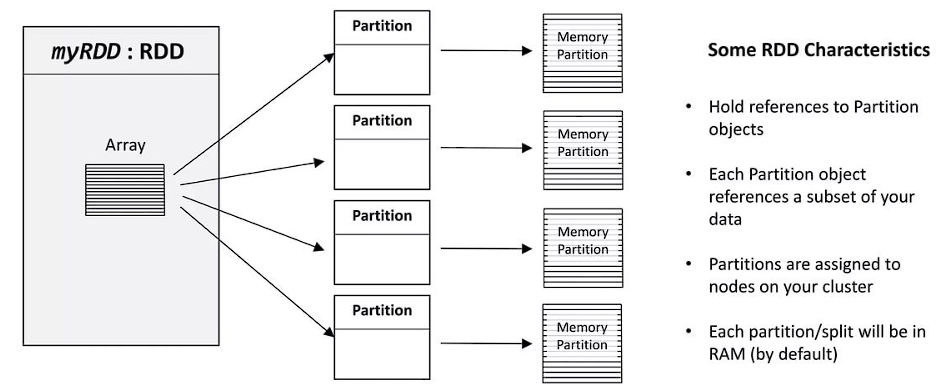

## Partitions

Partitions are small chunks of a large dataset spread across different cluster nodes. Spark processes data in parallel, so instead of one big task, it runs many small tasks on these chunks simultaneously. It’s essential for performance because more partitions allow more executors to work at the same time, speeding up the whole job.

Initially, our Dataframe is stored as one partition due to its small size. The default partition size is 128 MB in `Spark`.

In [ ]:
df_grouped = df.withColumn('partition_id', spark_partition_id()).groupBy('partition_id').count()
df_grouped.display()

partition_id,count
0,95


Create 4 partitions instead of 1.

In [ ]:
df = df.repartition(4)
df.withColumn('partition_id', spark_partition_id()).groupBy('partition_id').count().display()

partition_id,count
0,23
1,24
2,24
3,24


In [ ]:
df.rdd.getNumPartitions()

1

What if we change it to 128 KB?

In [ ]:
spark.conf.set('spark.sql.files.maxPartitionBytes', 131072)

Now we have 7 partitions.

In [ ]:
df = spark.read.format('csv') \
    .option('inferSchema', True) \
    .option('header', True) \
    .load(getpath('BigMart Sales.csv'))
df.rdd.getNumPartitions()

7

Change it back.

In [ ]:
spark.conf.set('spark.sql.files.maxPartitionBytes', 134217728)

In [ ]:
df = df.repartition(10)

In [ ]:
df.withColumn('partition_id', spark_partition_id()).toPandas()


## Dynamic partition pruning

Dynamic partition pruning is a runtime optimization that skips reading irrelevant partition directories by using filter values computed during query execution. In a typical scenario with a filtered broadcasted or joined small table, Spark computes the set of join key values from the probe side, often from a broadcast, and uses those values to prune which partitions of the larger table need to be read.

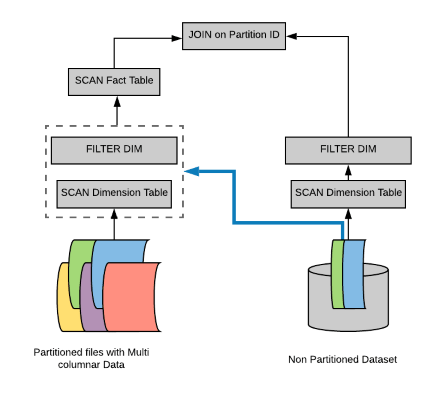

## Repartition and coalesce

Repartition is an operation that changes the number of partitions by performing a full shuffle across the cluster, producing evenly balanced partitions. Use to increase or evenly redistribute partitions.

Coalesce is an operation that changes the number of partitions by merging existing partitions without a full shuffle (fast) — may produce uneven partition sizes. To increase partitions or rebalance, call coalesce(..., shuffle=True) or use repartition.

| Aspect | Repartition | Coalesce |
|---|---:|---:|
| Shuffle | always | optional via shuffle=True |
| Can increase partitions | Yes | Only with shuffle=True |
| Partition balance | Even | May be skewed when no shuffle |
| Performance cost | Higher network and disk | Lower and faster when no shuffle |

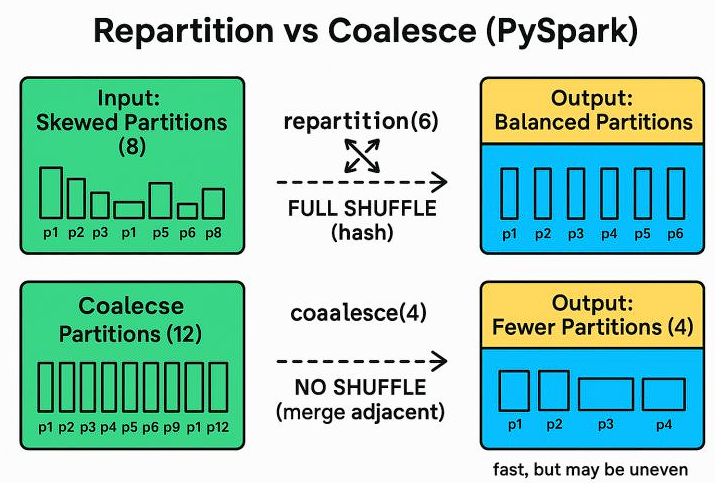

In [ ]:
df = spark.range(100).repartition(10)
df2 = df.coalesce(4)
df2.rdd.getNumPartitions() # 4

## Caching

Spark uses lazy evaluation: transformations are recomputed when a DataFrame or Dataset is accessed unless results are persisted. Persistence, called cache or persist, saves intermediate data in memory or on disk to avoid repeated computation or source reads.

`StorageLevel.DISK_AND_MEMORY` is a valid storage level but caching usually refers to in-memory storage such as `MEMORY_ONLY`. `MEMORY_AND_DISK` is more commonly used to keep data in memory first and spill to disk when memory is insufficient.

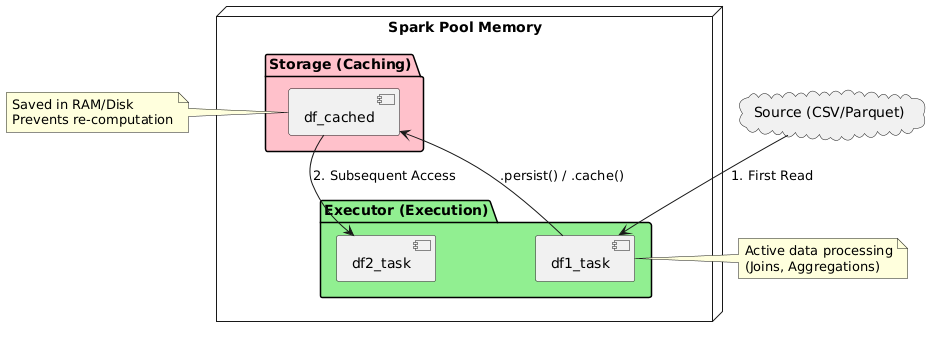

In [ ]:
df = spark.read.format('csv') \
    .option('inferSchema', True) \
    .option('header', True) \
    .load(getpath('BigMart Sales.csv')) \
    .cache()

In [ ]:
df2 = df.filter(col('Outlet_Location_Type') == 'Tier 1')
df3 = df.filter(col('Outlet_Location_Type') == 'Tier 2')

Remove from cache.

In [ ]:
df.unpersist()

DataFrame[Item_Identifier: string, Item_Weight: double, Item_Fat_Content: string, Item_Visibility: double, Item_Type: string, Item_MRP: double, Outlet_Identifier: string, Outlet_Establishment_Year: int, Outlet_Size: string, Outlet_Location_Type: string, Outlet_Type: string, Item_Outlet_Sales: double]

In [ ]:
from pyspark.storagelevel import StorageLevel

df.persist(StorageLevel.MEMORY_ONLY)

DataFrame[Item_Identifier: string, Item_Weight: double, Item_Fat_Content: string, Item_Visibility: double, Item_Type: string, Item_MRP: double, Outlet_Identifier: string, Outlet_Establishment_Year: int, Outlet_Size: string, Outlet_Location_Type: string, Outlet_Type: string, Item_Outlet_Sales: double]

## Scanning optimisation

`Parquet` is a columnar storage format that's much faster and more efficient than `CSV`. Instead of reading entire rows, `Spark` can skip unnecessary columns and only load the data you actually need. It also supports compression and stores the schema inside the file, so you don't lose information. Because it's binary, it takes up way less space. `Delta` stores files in this format but additionally writes logs.


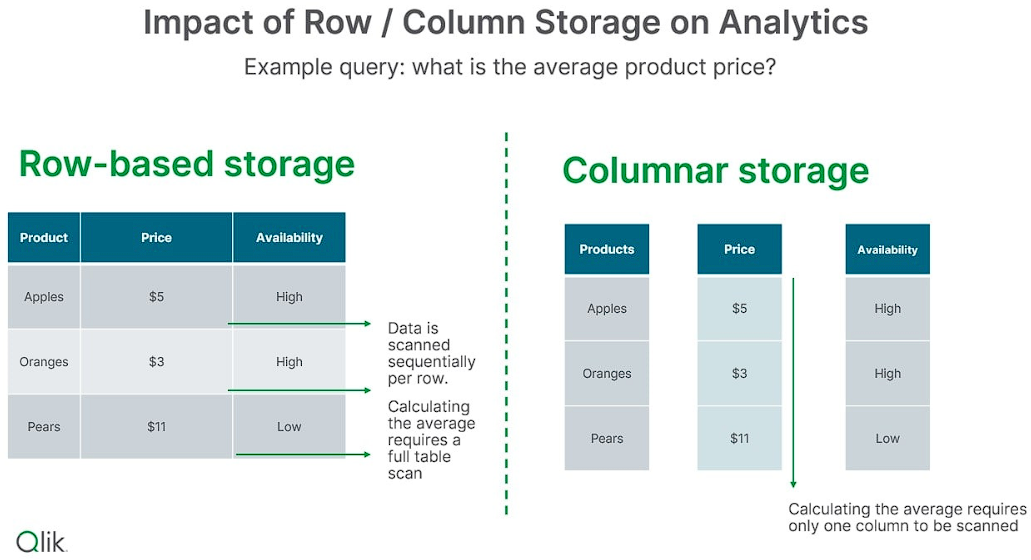

Save as parquet, read, and filter.

In [ ]:
df.write.format('parquet') \
    .mode('append') \
    .option('path', getpath('rawdata/parquetWrite')) \
    .save()

In [ ]:
df_new = spark.read.format('parquet') \
    .load(getpath('rawdata/parquetWrite'))
df_new = df_new.filter(col('Outlet_Location_Type') == 'Tier 1')
df_new.toPandas()

Create a separate folder for each `Tier` so we needn't read all the 10 original partitions to search the `Tier 1`.

In [ ]:
df.write.format('parquet') \
    .mode('append') \
    .partitionBy('Outlet_Location_Type') \
    .option('path', getpath('rawdata/parquetWriteOpt')) \
    .save()

In [ ]:
df_new = df_new.filter(col('Outlet_Location_Type') == 'Tier 1')

## Dynamic Resource Allocation

Dynamic allocation allows Spark to adjust the number of executors based on the workload. This helps optimize resource usage by releasing idle executors and requesting new ones when demand increases. Parameters:

- `spark.dynamicAllocation.enabled` activates the dynamic scaling feature.
- `spark.shuffle.service.enabled` required to preserve shuffle files after executors are removed.
- `min/maxExecutors` boundaries for scaling to ensure job stability and cost control.

In [ ]:
spark = SparkSession.builder \
    .appName("my_spark_job") \
    .config("spark.dynamicAllocation.enabled", "true") \
    .config("spark.shuffle.service.enabled", "true") \
    .config("spark.dynamicAllocation.minExecutors", "1") \
    .config("spark.dynamicAllocation.initialExecutors", "4") \
    .config("spark.dynamicAllocation.maxExecutors", "10") \
    .getOrCreate()

## Salting

Salting is a technique of adding a random or pseudorandom prefix to a key value under heavy skew to distribute data evenly across partitions, followed by desalting (removing the prefix) before final aggregation or join. In the df the A key has a high skew.

In [ ]:
data = [("A", 10), ("A", 20), ("A", 30), ("B", 5), ("C", 1)]
df = spark.createDataFrame(
    [
        ("A", 10), ("A", 20),
        ("A", 30), ("B", 5),
        ("C", 1)
    ], ["key", "value"]
)
df.toPandas()

,key,value
0,A,10
1,A,20
2,A,30
3,B,5
4,C,1


Create two balanced groups.

In [ ]:
salted = df.withColumn("salt", floor(rand() * 2).cast("int")) \
    .withColumn("salted_key", concat(col("key"), lit("_"), col("salt")))
salted.toPandas()

,key,value,salt,salted_key
0,A,10,0,A_0
1,A,20,1,A_1
2,A,30,1,A_1
3,B,5,1,B_1
4,C,1,0,C_0


In [ ]:
agg_salted = salted.groupBy("salted_key").sum("value") \
    .withColumnRenamed("sum(value)", "partial_sum")
agg_salted.toPandas()

,salted_key,partial_sum
0,A_0,10
1,A_1,50
2,B_1,5
3,C_0,1


In [ ]:
desalted = agg_salted.withColumn("key", split(col("salted_key"), "_").getItem(0))
desalted.groupBy("key").sum("partial_sum").toPandas()

,key,sum(partial_sum)
0,B,5
1,C,1
2,A,60


## Z-ordering

Z-ordering is a method of physically ordering data by multiple columns using a Z‑curve so that rows with similar values are stored close together on disk, which speeds up data skipping in Delta Lake. The method is based on Morton space-filling curve

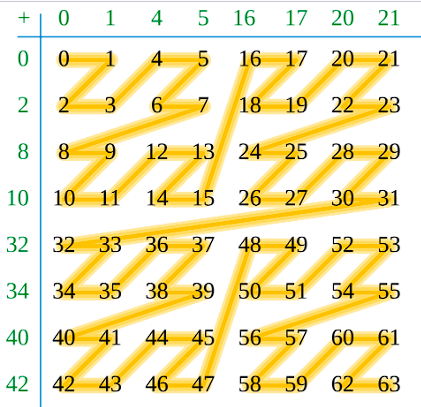

In [ ]:
spark.sql("CREATE DATABASE IF NOT EXISTS schema1")

DataFrame[]

In [ ]:
spark.sql("CREATE DATABASE IF NOT EXISTS schema1")
spark.sql("USE schema1")

schema = StructType([
    StructField("id", IntegerType(), False),
    StructField("salary", IntegerType(), False),
])
data = [(1, 50000), (2, 60000), (3, 70000)]
df = spark.createDataFrame(data, schema)

df.write.mode("overwrite").saveAsTable("schema1.employee")

spark.sql("SELECT * FROM schema1.employee").toPandas()

,id,salary
0,2,60000
1,3,70000
2,1,50000


In [ ]:
spark.sql("OPTIMIZE delta.'schema1.employee' ZORDER BY (id)")